https://www.kaggle.com/datasets/ashfakyeafi/air-passenger-data-for-time-series-analysis

Bộ dữ liệu này được thiết kế để giúp người học và nhà khoa học dữ liệu rèn luyện các kỹ năng:

Phân tích xu hướng (Trend): Nhìn nhận sự phát triển hoặc suy giảm lượng hành khách qua các năm.

Phân tích tính mùa vụ (Seasonality): Nhận diện các chu kỳ lặp lại đều đặn theo từng tháng trong năm (ví dụ: lượng khách thường tăng vọt vào mùa du lịch hè hoặc dịp lễ tết).

Xây dựng mô hình dự báo: Áp dụng các thuật toán kinh điển như ARIMA, SARIMA, Prophet, Exponential Smoothing, hay các mô hình Học máy/Học sâu (LSTM, Transformer) để dự đoán số lượng hành khách trong tương lai.

Bộ dữ liệu thường có cấu trúc dạng bảng (CSV) đơn giản gồm hai cột chính:

Cột Thời gian (Date / Month / Year-Month): Ghi nhận mốc thời gian (thường theo tháng hoặc theo ngày tùy phiên bản cụ thể).

Cột Số lượng hành khách (Passengers / Total Passengers): Biểu thị tổng số lượng hành khách di chuyển bằng đường hàng không trong khoảng thời gian tương ứng.

3. Các đặc điểm nổi bật của chuỗi thời gian hàng không
Khi phân tích tập dữ liệu này, bạn sẽ thấy rõ ba thành phần kinh điển của chuỗi thời gian:

Xu hướng tăng trưởng dài hạn (Trend): Càng về các năm sau, nhu cầu đi lại bằng máy bay càng tăng lên do kinh tế phát triển và ngành hàng không mở rộng.

Biến động mùa vụ (Seasonality): Biên độ dao động tăng giảm diễn ra đều đặn hàng năm (ví dụ: các tháng mùa hè có lượng khách cao hơn hẳn các tháng thấp điểm).

Phương sai thay đổi (Non-stationary): Khi quy mô hành khách lớn hơn ở các năm sau, biên độ dao động theo mùa cũng lớn theo (mùa vụ mang tính nhân chéo thay vì cộng tính thuần túy).

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

In [57]:
data = pd.read_csv("AirPassengers.csv")

In [58]:
data.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [59]:
data.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [60]:
data["Month"] = pd.to_datetime(data["Month"])

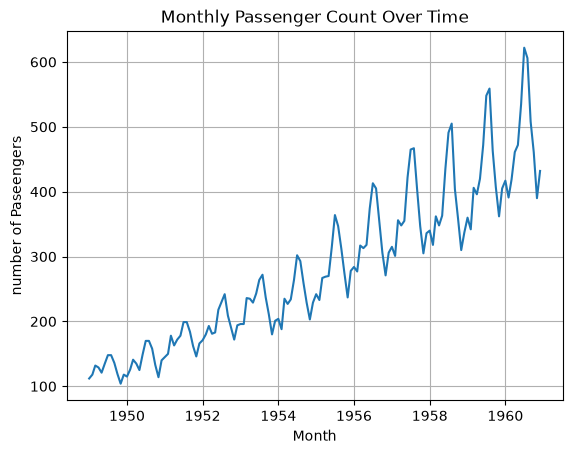

In [61]:
plt.plot(data["Month"],data["#Passengers"], label="Passenger Count")
plt.title("Monthly Passenger Count Over Time")
plt.xlabel("Month")
plt.ylabel("number of Paseengers")
plt.grid(True)
plt.show()

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


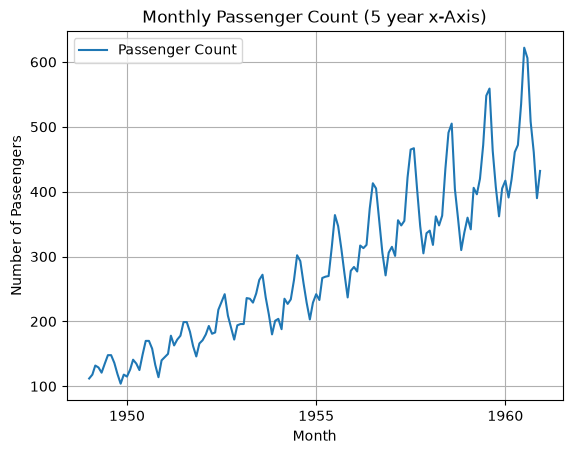

In [63]:
from matplotlib.dates import YearLocator
plt.plot(data["Month"],data["#Passengers"], label="Passenger Count")
plt.title("Monthly Passenger Count (5 year x-Axis)")
plt.xlabel("Month")
plt.ylabel("Number of Paseengers")
plt.grid(True)
plt.legend()

plt.gca().xaxis.set_major_locator(YearLocator(5))

In [64]:
from statsmodels.tsa.stattools import adfuller

In [65]:

time_series_data = data["#Passengers"]

In [66]:
result = adfuller(time_series_data)

C:\Users\mbw2025\AppData\Local\Temp\ipykernel_4348\3857209045.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(time_series_data)


In [67]:
print("ADF Statistic", result[0])
print("p-value", result[1])
print("Critical Values: ", result[4])

ADF Statistic 0.8153688792060576
p-value 0.9918802434376411
Critical Values:  {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


In [68]:
if result[1] <= 0.05:
    print("The time series is stationary")
else:
    print("The time series is not stationary")

The time series is not stationary


In [69]:
!pip install pmdarima

In [70]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [71]:
model = auto_arima(time_series_data, suppress_warnings=True, seasonal=False, stepwise=True)

In [72]:
order = model.get_params()["order"]

In [73]:
arima_model = ARIMA(time_series_data, order=order)

In [74]:
arima_result = arima_model.fit()

d:\A_Self_Proj\learn_mlflow\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
d:\A_Self_Proj\learn_mlflow\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


In [75]:
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(4, 1, 3)   Log Likelihood                -674.913
Date:                Mon, 05 Oct 2026   AIC                           1365.825
Time:                        10:03:37   BIC                           1389.528
Sample:                             0   HQIC                          1375.457
                                - 144                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5582      0.117     -4.782      0.000      -0.787      -0.329
ar.L2          0.4935      0.113      4.375      0.000       0.272       0.715
ar.L3          0.1238      0.128      0.970      0.332      -0.126       0.374
ar.L4         -0.5213      0.085     -6.136      0.000      -0.688      -0.355
ma.L1          0.9069      0.094      9.657      0.000       0.723       1.091
ma.L2         -0.5590      0.145     -3.866      0.000      -0.842      -0.276
ma.L3         -0.7385      0.109     -6.778      0.000      -0.952      -0.525
sigma2       724.1727     85.616      8.458      0.000     556.369     891.976
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                14.59
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

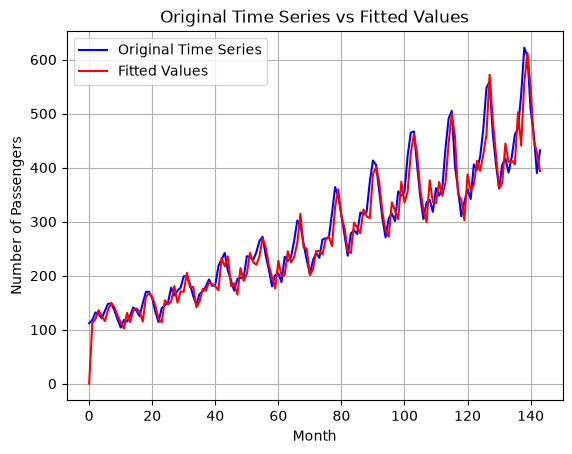

In [76]:
plt.plot(time_series_data, label="Original Time Series", color="blue")
plt.plot(arima_result.fittedvalues, label="Fitted Values", color="red") # Sửa 'lable' thành 'label'
plt.title("Original Time Series vs Fitted Values")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
forecast_step = 24

In [78]:
forecast_values = arima_result.get_forecast(steps=forecast_step).predicted_mean


In [79]:
forecast_index = pd.date_range(start = time_series_data.index[-1] + pd.DateOffset(months=1), periods=forecast_step, freq="M")

TypeError: unsupported operand type(s) for +: 'int' and 'DateOffset'

In [ ]:
forecast_index

DatetimeIndex(['1970-02-28 00:00:00.000000143',
               '1970-03-31 00:00:00.000000143',
               '1970-04-30 00:00:00.000000143',
               '1970-05-31 00:00:00.000000143',
               '1970-06-30 00:00:00.000000143',
               '1970-07-31 00:00:00.000000143',
               '1970-08-31 00:00:00.000000143',
               '1970-09-30 00:00:00.000000143',
               '1970-10-31 00:00:00.000000143',
               '1970-11-30 00:00:00.000000143',
               '1970-12-31 00:00:00.000000143',
               '1971-01-31 00:00:00.000000143',
               '1971-02-28 00:00:00.000000143',
               '1971-03-31 00:00:00.000000143',
               '1971-04-30 00:00:00.000000143',
               '1971-05-31 00:00:00.000000143',
               '1971-06-30 00:00:00.000000143',
               '1971-07-31 00:00:00.000000143',
               '1971-08-31 00:00:00.000000143',
               '1971-09-30 00:00:00.000000143',
               '1971-10-31 00:00:00.0000

Đang tìm kiếm thông số tối ưu cho mô hình SARIMA...
                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  120
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 201.768
Date:                              Mon, 05 Oct 2026   AIC                           -393.536
Time:                                      10:08:54   BIC                           -380.126
Sample:                                  01-01-1949   HQIC                          -388.099
                                       - 12-01-1958                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0178      0.010      1.798   

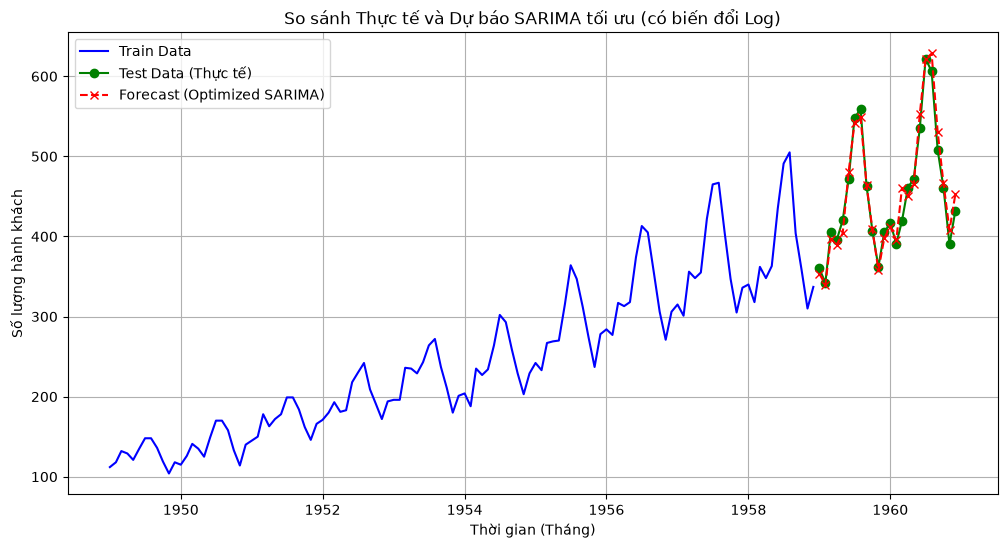

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# 1. Đọc và chuẩn hóa dữ liệu
data = pd.read_csv("AirPassengers.csv")
data["Month"] = pd.to_datetime(data["Month"])
data = data.set_index("Month")
time_series_data = data["#Passengers"]

# 2. Chia tập Train và Test (Test lấy 24 tháng cuối cùng)
forecast_step = 24
train_data = time_series_data[:-forecast_step]
test_data = time_series_data[-forecast_step:]

# 3. Biến đổi Logarit để xử lý tính mùa vụ nhân chéo (biên độ tăng dần theo thời gian)
train_log = np.log(train_data)

# 4. Dùng auto_arima tự động tìm mô hình SARIMA tối ưu nhất
print("Đang tìm kiếm thông số tối ưu cho mô hình SARIMA...")
auto_model = auto_arima(
    train_log, 
    seasonal=True, 
    m=12,               # Chu kỳ mùa vụ = 12 tháng
    suppress_warnings=True, 
    stepwise=True       # Dò tìm nhanh
)

print(auto_model.summary())

# 5. Dự báo 24 bước trên không gian Log
forecast_log, conf_int_log = auto_model.predict(n_periods=forecast_step, return_conf_int=True)

# 6. Chuyển ngược lại không gian thực bằng hàm mũ (np.exp)
forecast_values = np.exp(forecast_log)
forecast_series = pd.Series(forecast_values.values, index=test_data.index)

# 7. Tạo bảng so sánh Actual vs Forecast và tính % sai lệch
comparison_df = pd.DataFrame({
    "Actual": test_data,
    "Forecast": forecast_series
})

comparison_df["Absolute Error"] = (comparison_df["Actual"] - comparison_df["Forecast"]).abs()
comparison_df["% Error"] = (comparison_df["Absolute Error"] / comparison_df["Actual"]) * 100

print("\n--- BẢNG SO SÁNH DỮ LIỆU THỰC TẾ VÀ DỰ BÁO (OPTIMIZED SARIMA + LOG) ---")
print(comparison_df.to_string())

# 8. Vẽ biểu đồ so sánh trực quan
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label="Train Data", color="blue")
plt.plot(test_data.index, test_data, label="Test Data (Thực tế)", color="green", marker="o")
plt.plot(forecast_series.index, forecast_series, label="Forecast (Optimized SARIMA)", color="red", linestyle="--", marker="x")

plt.title("So sánh Thực tế và Dự báo SARIMA tối ưu (có biến đổi Log)")
plt.xlabel("Thời gian (Tháng)")
plt.ylabel("Số lượng hành khách")
plt.legend()
plt.grid(True)
plt.show()

In [90]:
import joblib

# Cách 1: Lưu trực tiếp đối tượng kết quả huấn luyện (fitted model) bằng joblib
model_filename = "sarima_air_passenger_model.pkl"
joblib.dump(result, model_filename)
print(f"Đã lưu mô hình thành công vào file: {model_filename}")

# Hoặc dùng hàm save() có sẵn của statsmodels:
# result.save("sarima_model.pkl")

Đã lưu mô hình thành công vào file: sarima_air_passenger_model.pkl


In [91]:
import pandas as pd
import numpy as np
import joblib

# 1. Tải lại mô hình đã lưu
loaded_model = joblib.load("sarima_air_passenger_model.pkl")

# 2. Thực hiện dự báo tiếp N bước tương lai (ví dụ: dự báo thêm 12 tháng tiếp theo)
future_steps = 12
forecast_log_new = loaded_model.get_forecast(steps=future_steps)

# Lấy giá trị trung bình dự báo trên không gian Log
predicted_log_values = forecast_log_new.predicted_mean

# 3. Đổi ngược từ không gian Log về giá trị thực tế bằng np.exp()
predicted_actual_values = np.exp(predicted_log_values)

print("Kết quả dự báo cho dữ liệu mới:")
print(predicted_actual_values)

Kết quả dự báo cho dữ liệu mới:
1959-01-01    1.828284e+148
1959-02-01    3.538825e+138
1959-03-01    4.652378e+157
1959-04-01    3.278840e+151
1959-05-01    1.432745e+158
1959-06-01    1.945358e+189
1959-07-01    4.243508e+213
1959-08-01    5.573841e+219
1959-09-01    4.939260e+175
1959-10-01    1.835344e+156
1959-11-01    1.018947e+135
1959-12-01    4.246238e+146
Freq: MS, Name: predicted_mean, dtype: float64
